# 02 — GTA-wide risk hotspot index

Where do **hidden rivers** and **weak (aging) sewers** coincide — and does observed flooding
line up with them? For each ward we normalise three signals to 0–1 and combine them:

| score | from | meaning |
|---|---|---|
| `river_score` | buried-river density (km / km²) | how much hidden river runs under the ward |
| `weaksewer_score` | aging-sewer density (km of pre-1960 sewer / km²) | how much weak sewer capacity |
| `flood_score` | mean basement floods 2005–2022 | observed outcome |

* **`coincidence_index`** = geometric mean of `river_score` × `weaksewer_score` — high **only**
  where *both* a buried river and aging sewers are present (the headline hotspot map).
* **`risk_index`** = mean of all three — a broader composite that also weights observed floods.

Output `ward_risk_scores.geojson` is read by the app's **Risk Hotspots** tab.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parents[0]))
import lib
import geopandas as gpd, pandas as pd
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 40)

# Static infra features from notebook 01 (rebuild if not yet saved)
p = lib.processed_dir() / 'ward_static_features.geojson'
static = gpd.read_file(p) if p.exists() else lib.build_ward_static_features()
print('wards:', len(static), '| from', 'saved geojson' if p.exists() else 'rebuild')

wards: 25 | from saved geojson


## Component scores

In [2]:
# Observed flood intensity per ward (mean over 2005–2022)
floods = lib.load_basement_floods_long()
flood_mean = floods.groupby('ward_num')['flood_count'].mean().rename('flood_mean')
static = static.merge(flood_mean, on='ward_num', how='left')
static['flood_mean'] = static['flood_mean'].fillna(0.0)

static['weaksewer_density'] = static['weak_sewer_km'] / static['area_km2']
static['river_score']      = lib.minmax(static['river_density'])
static['weaksewer_score']  = lib.minmax(static['weaksewer_density'])
static['flood_score']      = lib.minmax(static['flood_mean'])

static['coincidence_index'] = (static['river_score'] * static['weaksewer_score']) ** 0.5
static['risk_index'] = static[['river_score','weaksewer_score','flood_score']].mean(axis=1)
print('scores computed for', len(static), 'wards')

scores computed for 25 wards


## Top hotspots

Sanity check: high-coincidence wards should fall over known buried-creek corridors and
high-flood wards.

In [3]:
show = ['ward_num','ward_name','river_score','weaksewer_score','flood_score',
        'coincidence_index','risk_index']
print('— Top 10 by hidden-river × weak-sewer coincidence —')
display(static[show].sort_values('coincidence_index', ascending=False).head(10).round(2))
print('— Top 10 by overall risk index —')
display(static[show].sort_values('risk_index', ascending=False).head(10).round(2))

— Top 10 by hidden-river × weak-sewer coincidence —


,ward_num,ward_name,river_score,weaksewer_score,flood_score,coincidence_index,risk_index
21,13,Toronto Centre,1.00,1.00,0.61,1.00,0.87
17,8,Eglinton-Lawrence,0.69,0.63,0.03,0.66,0.45
4,19,Beaches-East York,0.56,0.75,0.57,0.65,0.62
22,5,York South-Weston,0.30,0.86,1.00,0.51,0.72
11,15,Don Valley West,0.29,0.86,0.64,0.50,0.60
23,14,Toronto-Danforth,0.35,0.54,0.50,0.43,0.46
19,16,Don Valley East,0.33,0.54,0.47,0.42,0.45
12,12,Toronto-St. Paul's,0.46,0.32,0.42,0.39,0.40
24,10,Spadina-Fort York,0.26,0.38,0.28,0.31,0.31
1,6,York Centre,0.30,0.27,0.88,0.28,0.48


— Top 10 by overall risk index —


,ward_num,ward_name,river_score,weaksewer_score,flood_score,coincidence_index,risk_index
21,13,Toronto Centre,1.00,1.00,0.61,1.00,0.87
22,5,York South-Weston,0.30,0.86,1.00,0.51,0.72
4,19,Beaches-East York,0.56,0.75,0.57,0.65,0.62
11,15,Don Valley West,0.29,0.86,0.64,0.50,0.60
1,6,York Centre,0.30,0.27,0.88,0.28,0.48
3,11,University-Rosedale,0.48,0.00,0.91,0.00,0.46
23,14,Toronto-Danforth,0.35,0.54,0.50,0.43,0.46
17,8,Eglinton-Lawrence,0.69,0.63,0.03,0.66,0.45
19,16,Don Valley East,0.33,0.54,0.47,0.42,0.45
12,12,Toronto-St. Paul's,0.46,0.32,0.42,0.39,0.40


## Static hotspot map

wrote /h/u7/c3/05/fuhrerhu/hidden-rivers/docs/hotspot_map.png


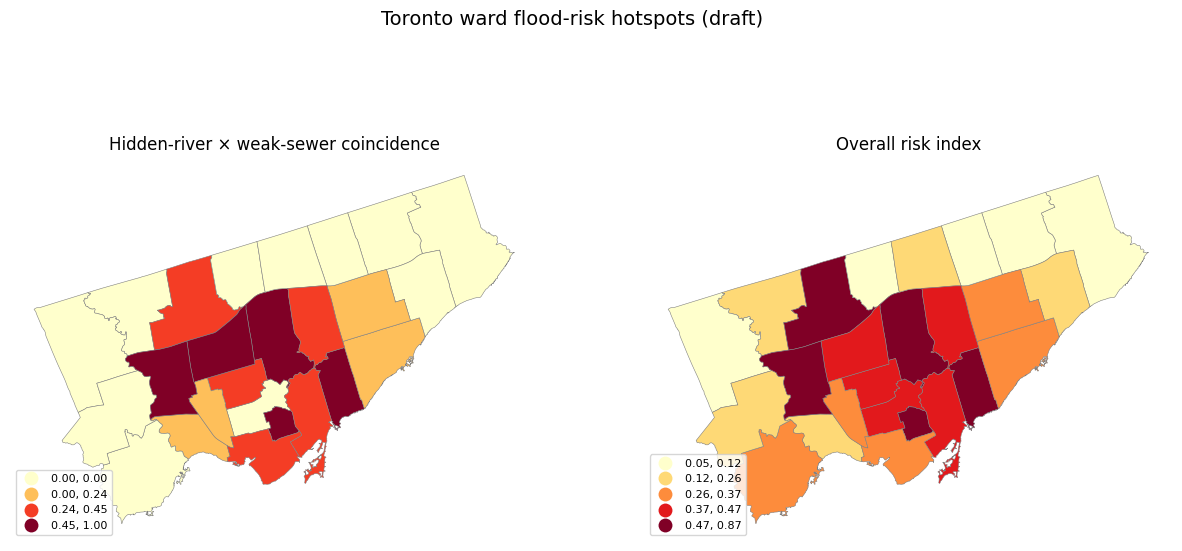

In [4]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, col, title in [(axes[0], 'coincidence_index', 'Hidden-river × weak-sewer coincidence'),
                       (axes[1], 'risk_index', 'Overall risk index')]:
    static.plot(column=col, cmap='YlOrRd', scheme='quantiles', k=5, legend=True,
                edgecolor='0.5', linewidth=0.4, ax=ax,
                legend_kwds={'fontsize': 8, 'loc': 'lower left'})
    ax.set_title(title, fontsize=12); ax.axis('off')
fig.suptitle('Toronto ward flood-risk hotspots (draft)', fontsize=14)
png = lib.REPO / 'docs' / 'hotspot_map.png'
fig.savefig(png, dpi=120, bbox_inches='tight')
print('wrote', png)
plt.show()

## Save artifact for the app

In [5]:
keep = ['ward_num','ward_name','geometry','river_density','weaksewer_density','flood_mean',
        'river_score','weaksewer_score','flood_score','coincidence_index','risk_index']
out = lib.processed_dir() / 'ward_risk_scores.geojson'
static[keep].to_file(out, driver='GeoJSON')
print('wrote', out, f'({len(static)} wards, {len(keep)-1} score columns)')

wrote /h/u7/c3/05/fuhrerhu/hidden-rivers/data/processed/ward_risk_scores.geojson (25 wards, 10 score columns)
